### Задание

1. Выберите любой из рядов для работы (можно поэкспериментировать с несколькими рядами)
2. Аналогично лекционному ноутбуку подберите оптимальные параметры ARIMA для ряда
3. Используя найденные параметры, постройте модель Garch этого ряда
Не забудьте, что Garch работает только со стационарными рядами (!)
4. Сделайте выводы по полученным результатам, насколько хорошо Garch подходит для выбранного ряда

In [4]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.5/927.5 kB 3.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm
import statsmodels.tsa.api as smt
from scipy.stats import boxcox

## Подготовка функций и данных

In [83]:
airlines_passengers = pd.read_csv("/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Модели ARCH и GARCH/Материалы к занятию «Знакомство с временными рядами»/Series/international-airline-passengers.csv")


### Визуализация

In [8]:
def plot_(model,series,title):
    with plt.style.context('bmh'):
        plt.figure(figsize=(8, 8))
        if model == None:
            plt.plot(series, color='blue', linewidth='2', label='Real')
        else:
            plt.plot(model, color='red', linewidth='2', label='Pred')
            plt.plot(series, color='blue', linewidth='2', label='Real')
        plt.legend()
        plt.title(f'{title}')

    plt.show()

In [10]:
def test_stationarity(series):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [11]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1) ## виртуальная сетка таблицы
        ## расположение графиков внутри виртуальной сетки
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2) 
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or') ## исходный график
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05) ## график автокрреляции
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05) ## график частичной автокорреляции
        sm.qqplot(y, line='s', ax=qq_ax) ## график квантилей
        
        plt.show()
    return

### Поиск параметров

In [12]:
def search_param_ARIMA (series):
    best_aic = np.inf
    best_param = None
    best_model = None

    for i in range (7):
        for j in range(7):
            for d in range(7):
                try:
                    model = ARIMA(series,order=(i,d,j),trend='n').fit()
                    model_aic = model.aic
                    if model_aic < best_aic:
                        best_aic = model_aic
                        best_param = (i,d,j)
                        best_model= model
                except: continue

    print(f'Информационный критерий - {best_aic}, параметры - {best_param}')
    return best_param

### Модель GARCH

In [123]:
def GARCH_model(series,param):
    ## приводим ряд к стационарному
    series = boxcox(series, 0)
    series = series[1:] - series[:-1]
    series = series[12:] - series[:-12]
    series = series[12:] - series[:-12]
    series = series[24:] - series[:-24]
    series = series[36:] - series[:-36]
    
    

    p_,o_,q_ = param
  
    am = arch_model(series, p=p_, o=o_, q=q_, dist='StudentsT')
    res = am.fit(update_freq=5, disp='off')
    return res

### Функция для предсказаний

In [35]:

def plot_pred(series, steps):
    with plt.style.context(style='bmh'):
        best_param = search_param_ARIMA(series=airlines_passengers['Count'])
        model = GARCH_model(series=series, param=(6,1,6)) 
        
        # прогноз условной дисперсии
        forecast = model.forecast(horizon=steps)

        plt.figure(figsize=(14,8))
        plt.plot(series, color='red', label='Series')

        # достаем прогноз стандартного отклонения от ряда
        sigma_forecast = np.sqrt(forecast.variance.values[-1, :])
        plt.plot(range(len(series), len(series)+steps), sigma_forecast, 
                 color='blue', linestyle="--", label=f"GARCH {steps}-шагов вперёд")

        plt.legend()
        plt.show()

## Реализация для первого ряда

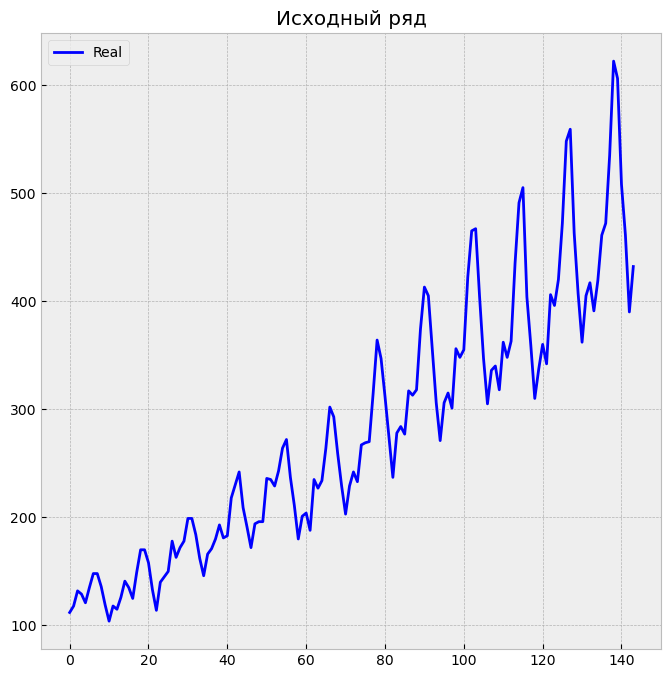

In [135]:
plot_(model=None,series=airlines_passengers['Count'],title='Исходный ряд')

Информационный критерий - 1310.451468565713, параметры - (6, 1, 6)
Results of Dickey-Fuller Test:
Test Statistic                -1.169230e+01
p-value                        1.641685e-21
#Lags Used                     0.000000e+00
Number of Observations Used    5.800000e+01
Critical Value (1%)           -3.548494e+00
Critical Value (5%)           -2.912837e+00
Critical Value (10%)          -2.594129e+00
dtype: float64


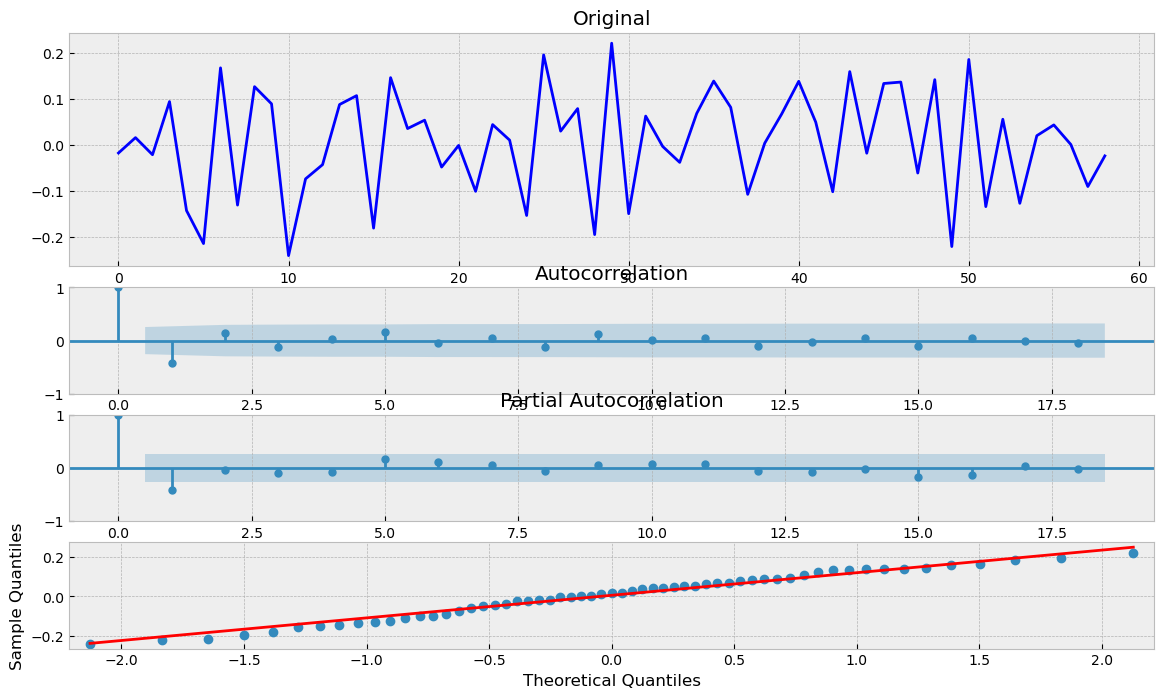

In [125]:
best_param = search_param_ARIMA(series=airlines_passengers['Count'])
tsplot(GARCH_model(series=airlines_passengers['Count'], param=best_param).resid)

### Выводы

Модель GARCH стала хорошо предсказывать временной ряд только после того, как с рядом были проделаны следующие операции: преобразование boxcox для нормализации дисперсии, дифференцирование с лагом 1 для удаление тренда ряда, два дифференцирования с лагом 12 для избавления сезонности, дифференцирование с лагом 24 и дифференцирование с лагом 36. Данные преобразования были сделаны по причине того, что, хоть и при трех первых преобразованиях значение p-value было меньше 0.05, но графики авторегрессии "проваливались" вниз, что демонстрировало нестационарность ряда. После этих преобразования такого больше не наблюдается, и график автокорелляции резко убывает. 

## Реализация для второго ряда

In [128]:
dowjones_closing= pd.read_csv("/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Модели ARCH и GARCH/Материалы к занятию «Знакомство с временными рядами»/Series/weekly-closings-of-the-dowjones-.csv")

,Week,Close
0,1971-W27,890.19
1,1971-W28,901.80
2,1971-W29,888.51
3,1971-W30,887.78
4,1971-W31,858.43
...,...,...
157,1974-W28,791.77
158,1974-W29,787.23
159,1974-W30,787.94
160,1974-W31,784.57


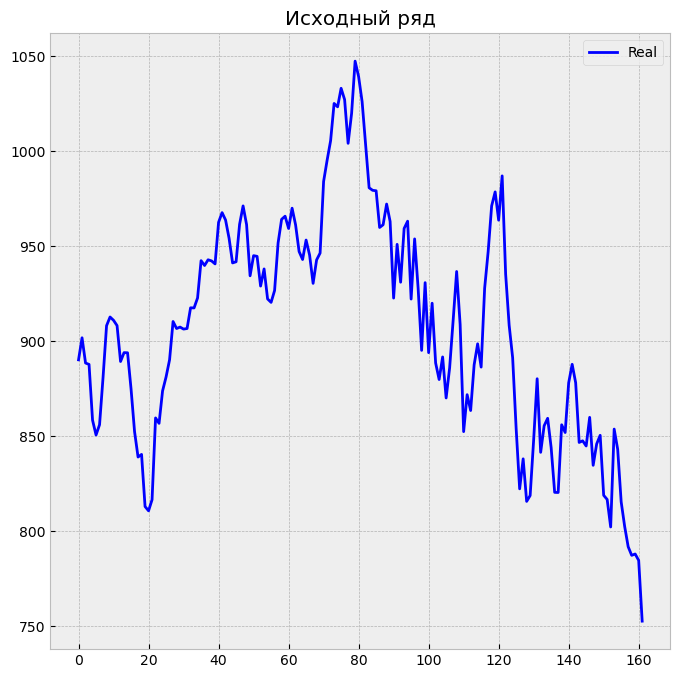

In [134]:
plot_(model=None,series=dowjones_closing['Close'],title='Исходный ряд')

In [148]:
def GARCH_model_2(series,param):
    ## приводим ряд к стационарному
    series = boxcox(series, 0)
    series = series[1:] - series[:-1]
    series = series[4:] - series[:-4]

    series = series[20:] - series[:-20]
    series = series[36:] - series[:-36]
    
    

    p_,o_,q_ = param
  
    am = arch_model(series, p=p_, o=o_, q=q_, dist='StudentsT')
    res = am.fit(update_freq=5, disp='off')
    return res

Информационный критерий - 22.0, параметры - (4, 6, 6)
Results of Dickey-Fuller Test:
Test Statistic                -8.843913e+00
p-value                        1.640207e-14
#Lags Used                     0.000000e+00
Number of Observations Used    7.600000e+01
Critical Value (1%)           -3.519481e+00
Critical Value (5%)           -2.900395e+00
Critical Value (10%)          -2.587498e+00
dtype: float64


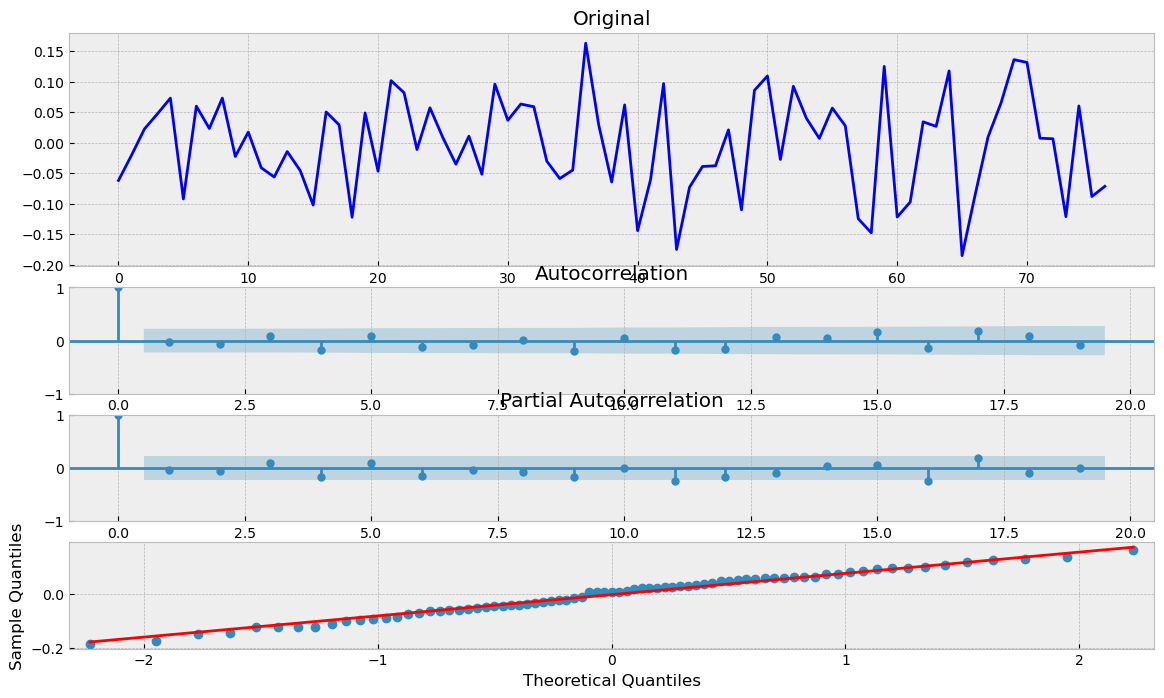

In [130]:
best_param = search_param_ARIMA(series=dowjones_closing['Close'])
tsplot(GARCH_model(series=dowjones_closing['Close'], param=best_param).resid)

Results of Dickey-Fuller Test:
Test Statistic                -6.322962e+00
p-value                        3.034371e-08
#Lags Used                     1.100000e+01
Number of Observations Used    8.900000e+01
Critical Value (1%)           -3.506057e+00
Critical Value (5%)           -2.894607e+00
Critical Value (10%)          -2.584410e+00
dtype: float64


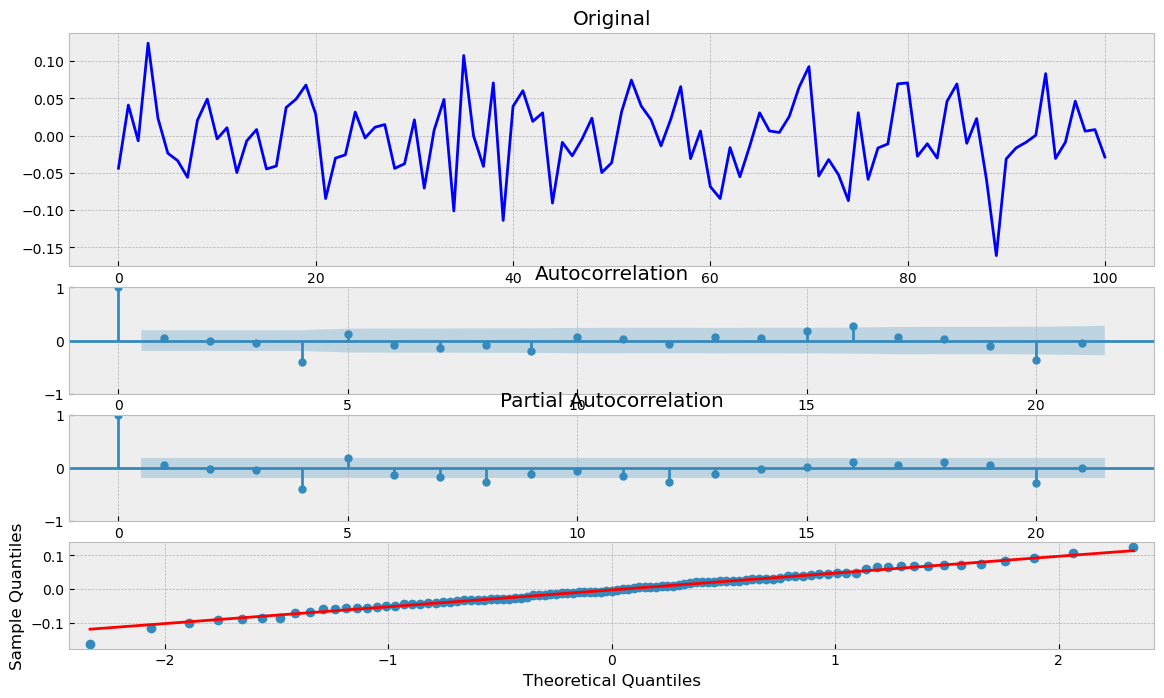

In [149]:
tsplot(GARCH_model_2(series=dowjones_closing['Close'], param=best_param).resid)

### Выводы
Для второго ряда лучше ведет себя модель, в предобработке данных которой были сделаны те же преобразования, что и для первого ряда, хотя модель с преобразованиями, в которых было включено дифференцирование по лагам 4 и 16 (сняты визуально по графику ряда), значением p-value подтверждает гипотезу о стационарности предсказанного ряда, то график авторегрессии так же проваливается в лаге 4. 